In [1]:
!pip install -q torch torchvision transformers scikit-learn matplotlib seaborn pandas

import os
import time
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, random_split, Dataset
from torchvision import datasets, transforms
from transformers import CLIPModel

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from IPython.display import FileLink, display

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cu128
CUDA available: True


In [2]:
DATASET_ROOT = "/kaggle/input/datasets/yangsangtai/tiny-genimage/imagenet_ai_0424_wukong"
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")

CONFIG = {
    "seed": 42,
    "image_size": 224,
    "batch_size": 32,
    "num_workers": 2,
    "num_epochs": 100,
    "learning_rate": 1e-3, 
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Official OpenAI CLIP Normalization Values
CLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
CLIP_STD = [0.26862954, 0.26130258, 0.27577711]

train_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(CLIP_MEAN, CLIP_STD),
])

raw_train = datasets.ImageFolder(TRAIN_DIR)
raw_val = datasets.ImageFolder(VAL_DIR)
full_dataset = ConcatDataset([raw_train, raw_val])

CLASS_TO_IDX = raw_train.class_to_idx
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

train_len = int(0.7 * len(full_dataset))
val_len = int(0.15 * len(full_dataset))
test_len = len(full_dataset) - train_len - val_len

train_subset, val_subset, test_subset = random_split(
    full_dataset, [train_len, val_len, test_len], generator=torch.Generator().manual_seed(CONFIG["seed"])
)

class TransformWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

train_loader = DataLoader(TransformWrapper(train_subset, train_transforms), batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader = DataLoader(TransformWrapper(val_subset, val_test_transforms), batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader = DataLoader(TransformWrapper(test_subset, val_test_transforms), batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

In [3]:
# 1. Load the official CLIP ViT-L/14 model
print("Loading CLIP ViT-L/14...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(DEVICE)
clip_model.eval()

# 2. Function to extract features exactly once
def extract_features(loader):
    features, labels_list = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            
            # Get the output from the CLIP model
            feats_output = clip_model.get_image_features(pixel_values=images)
            
            # Extract the raw tensor if transformers returns a model output object
            if hasattr(feats_output, "pooler_output"):
                feats = feats_output.pooler_output
            else:
                feats = feats_output
                
            # L2 normalize the features (standard practice for CLIP linear probing)
            feats = feats / feats.norm(p=2, dim=-1, keepdim=True)
            features.append(feats.cpu())
            labels_list.append(labels)
            
    return torch.cat(features), torch.cat(labels_list)

print("Extracting training features...")
X_train, y_train = extract_features(train_loader)

print("Extracting validation features...")
X_val, y_val = extract_features(val_loader)

print("Extracting test features...")
X_test, y_test = extract_features(test_loader)

print(f"Extracted training shape: {X_train.shape}")

Loading CLIP ViT-L/14...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting training features...
Extracting validation features...
Extracting test features...
Extracted training shape: torch.Size([3500, 768])


In [4]:
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)
CHECKPOINT_PATH = "/kaggle/working/checkpoints/clip_probe_best.pth"

# 1-Layer Classifier
classifier = nn.Linear(X_train.shape[1], 2).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=CONFIG["learning_rate"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

X_train, y_train = X_train.to(DEVICE), y_train.to(DEVICE)
X_val, y_val = X_val.to(DEVICE), y_val.to(DEVICE)

best_val_loss = float('inf')
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

start_time = time.time()

for epoch in range(1, CONFIG["num_epochs"] + 1):
    # Train
    classifier.train()
    optimizer.zero_grad()
    train_out = classifier(X_train)
    train_loss = criterion(train_out, y_train)
    train_loss.backward()
    optimizer.step()
    
    train_acc = (train_out.argmax(1) == y_train).float().mean().item()
    
    # Validate
    classifier.eval()
    with torch.no_grad():
        val_out = classifier(X_val)
        val_loss = criterion(val_out, y_val)
        val_acc = (val_out.argmax(1) == y_val).float().mean().item()
        
    scheduler.step(val_loss)
    
    history["train_loss"].append(train_loss.item())
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss.item())
    history["val_acc"].append(val_acc)
    
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        torch.save(classifier.state_dict(), CHECKPOINT_PATH)
        
    if epoch % 10 == 0 or epoch == 100:
        print(f"Epoch {epoch:03d}/{CONFIG['num_epochs']} | train_loss={train_loss.item():.4f} train_acc={train_acc:.4f} | val_loss={val_loss.item():.4f} val_acc={val_acc:.4f}")

elapsed = time.time() - start_time
print(f"\nLinear Probe trained in {elapsed:.1f} seconds. Best val_loss: {best_val_loss:.4f}")

# Reload best checkpoint
classifier.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

Epoch 010/100 | train_loss=0.6790 train_acc=0.6703 | val_loss=0.6784 val_acc=0.6773
Epoch 020/100 | train_loss=0.6648 train_acc=0.7791 | val_loss=0.6646 val_acc=0.7667
Epoch 030/100 | train_loss=0.6510 train_acc=0.8314 | val_loss=0.6511 val_acc=0.8093
Epoch 040/100 | train_loss=0.6377 train_acc=0.8520 | val_loss=0.6380 val_acc=0.8347
Epoch 050/100 | train_loss=0.6249 train_acc=0.8654 | val_loss=0.6255 val_acc=0.8480
Epoch 060/100 | train_loss=0.6126 train_acc=0.8691 | val_loss=0.6134 val_acc=0.8573
Epoch 070/100 | train_loss=0.6007 train_acc=0.8711 | val_loss=0.6018 val_acc=0.8600
Epoch 080/100 | train_loss=0.5893 train_acc=0.8771 | val_loss=0.5907 val_acc=0.8640
Epoch 090/100 | train_loss=0.5784 train_acc=0.8814 | val_loss=0.5799 val_acc=0.8640
Epoch 100/100 | train_loss=0.5678 train_acc=0.8834 | val_loss=0.5696 val_acc=0.8653

Linear Probe trained in 0.7 seconds. Best val_loss: 0.5696


<All keys matched successfully>

===== Classification Report (Test Set) =====
              precision    recall  f1-score   support

          ai       0.81      0.92      0.86       370
      nature       0.91      0.79      0.85       380

    accuracy                           0.86       750
   macro avg       0.86      0.86      0.86       750
weighted avg       0.86      0.86      0.86       750



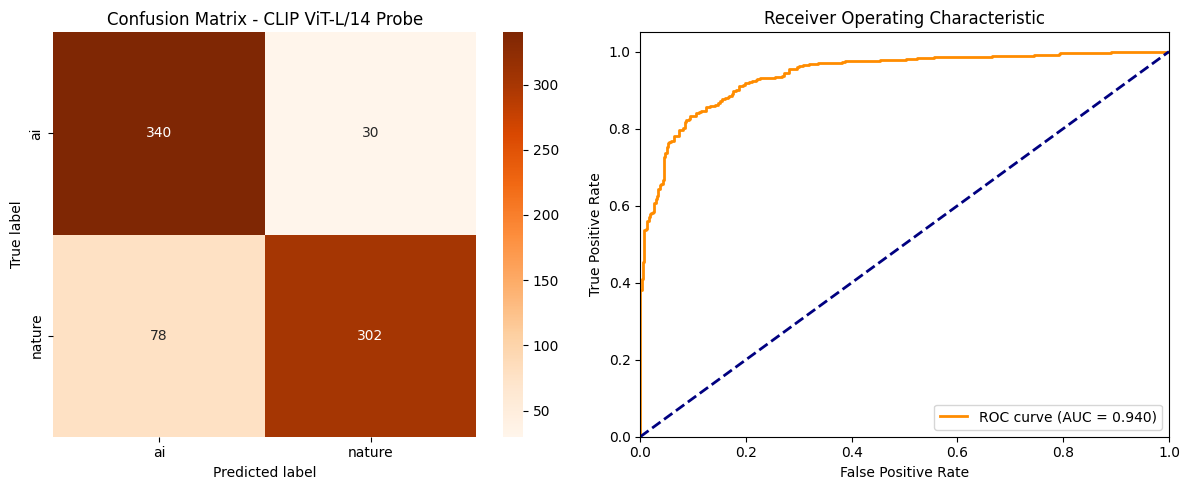

In [5]:
classifier.eval()

X_test, y_test = X_test.to(DEVICE), y_test.to(DEVICE)

with torch.no_grad():
    test_out = classifier(X_test)
    pos_idx = CLASS_TO_IDX.get("ai", 0)
    all_probs = torch.softmax(test_out, dim=1)[:, pos_idx].cpu().tolist()
    all_preds = test_out.argmax(dim=1).cpu().tolist()
    all_labels = y_test.cpu().tolist()

print("===== Classification Report (Test Set) =====")
print(classification_report(all_labels, all_preds, target_names=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]],
            yticklabels=[IDX_TO_CLASS[0], IDX_TO_CLASS[1]], ax=axes[0])
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title("Confusion Matrix - CLIP ViT-L/14 Probe")

fpr, tpr, thresholds = roc_curve(all_labels, all_probs, pos_label=pos_idx)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [6]:
 output_dir = "/kaggle/working/results"
os.makedirs(output_dir, exist_ok=True)

acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="binary", pos_label=pos_idx
)

results_row = {
    "dataset": "tiny_genimage_wukong",
    "model": "clip_vit_l_14_probe",
    "num_epochs": CONFIG["num_epochs"],
    "train_images": len(train_loader.dataset), # <-- Fixed: Extract length from the loader
    "test_images": len(test_loader.dataset),   # <-- Fixed: Extract length from the loader
    "test_accuracy": round(acc, 4),
    "test_precision": round(precision, 4),
    "test_recall": round(recall, 4),
    "test_f1_score": round(f1, 4),
    "test_auc": round(roc_auc, 4)
}

results_df = pd.DataFrame([results_row])
display(results_df)

RESULTS_CSV_PATH = os.path.join(output_dir, "clip_probe_test_results.csv")
results_df.to_csv(RESULTS_CSV_PATH, index=False)

FINAL_MODEL_PATH = os.path.join(output_dir, "clip_probe_best_model.pth")
shutil.copy(CHECKPOINT_PATH, FINAL_MODEL_PATH)

print("\n===== Download Links =====")
display(FileLink(RESULTS_CSV_PATH))
display(FileLink(FINAL_MODEL_PATH))

,dataset,model,num_epochs,train_images,test_images,test_accuracy,test_precision,test_recall,test_f1_score,test_auc
0,tiny_genimage_wukong,clip_vit_l_14_probe,100,3500,750,0.856,0.8134,0.9189,0.8629,0.9404



===== Download Links =====


/kaggle/working/results/clip_probe_test_results.csv

/kaggle/working/results/clip_probe_best_model.pth